In [1]:
#---------------------
#-------- Requirmenets
#---------------------

!pip install camel-tools
# !pip install nltk

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached nvidia_cuda_nvrtc_

## data prep

> this cell combines diagnosed and control REDDIT datasets into a single df, saved to colab.
ONLY COLUMNS RELEVANT TO FINETUNING ARE CONSIDERED.

```
'user_id', 'class', 'title', 'text', 'text_id'
```





In [ ]:
#------------REDDIT
#------------------------
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob

#--Diagnosed
diagnosed = pd.read_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Reddit Dataset/diagnosed.csv')
diagnosed = diagnosed[['user_id', 'selftext', 'id', 'title']].copy()
diagnosed.rename(columns={'selftext': 'text', 'id': 'text_id'}, inplace=True)

DATASET = "/content/drive/MyDrive/Social Mental Health Self-Discloser - Datasets/Reddit Dataset/Raw_Reddit_Dataset_Files"
files = glob.glob(DATASET + "/*.csv")
labels = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)[['Author', 'Condition']].copy()
labels.rename(columns={'Author': 'user_id', 'Condition': 'class'}, inplace=True)
labels = labels.dropna(subset=['user_id', 'class']).drop_duplicates()

conflicting_users = labels.groupby('user_id')['class'].nunique()
conflicting_users = conflicting_users[conflicting_users > 1].index
labels = labels[~labels['user_id'].isin(conflicting_users)].drop_duplicates(subset=['user_id'])

#--Merge labels
diagnosed = pd.merge(diagnosed, labels, on='user_id', how='left')
diagnosed = diagnosed[['user_id', 'class', 'title', 'text', 'text_id']]

#--Control
control = pd.read_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Control Dataset/control.csv')
control = control[['author', 'condition', 'title', 'selftext', 'id']].copy()
control.rename(columns={'selftext': 'text', 'id': 'text_id', 'author': 'user_id', 'condition': 'class'}, inplace=True)
control = control[['user_id', 'class', 'title', 'text', 'text_id']]

df = pd.concat([control, diagnosed], ignore_index=True)
df = df.sample(random_state=42, frac=1).reset_index(drop=True)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,user_id,class,title,text,text_id
0,AvishaiAhron,adhd,NaN,Health,nthbrgg
1,Samo_Adams,depression,Are there any more bugs beside these?,"I know we gonna get a final patch soon, I'm ju...",451sof
2,Interesting_Lunch_23,adhd,NaN,يمكن عشان بريطاني أو حاجة![gif](emote|free_emo...,kc7d0dg
3,No_Entry_2175,adhd,NaN,الله عليك يا عبغفور. ماشي بمبدأ معنديش حاجة أخ...,kxth0kw
4,Mysterious-Pace-5657,bpd,NaN,غلط عن غلط يفرق الضرب والتعنيف من المحرمات في...,mzmo1kq


In [3]:
#------------Twitter
#------------------------
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob

#--Diagnosed
diagnosed = pd.read_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Twitter Dataset/diagnosed.csv')
diagnosed = diagnosed[['username', 'tweet_text', 'tweet_id', 'diagnosis']].copy()
diagnosed.rename(columns={'tweet_text': 'text', 'tweet_id': 'text_id', 'username': 'user_id', 'diagnosis': 'class'}, inplace=True)

#--Control
control = pd.read_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Twitter Dataset/control_tweets/control_20260312_180904.csv')
control = control[['user_id', 'text', 'tweet_id', 'label']].copy()
control.rename(columns={'tweet_id': 'text_id', 'label': 'class'}, inplace=True)
control = control[['user_id', 'class', 'text', 'text_id']]

df = pd.concat([control, diagnosed], ignore_index=True)
df = df.sample(random_state=42, frac=1).reset_index(drop=True)
df.to_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Twitter Dataset/diagnosed-control.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# sanity check
common_users = set(control['user_id'].dropna().astype(str)) & set(diagnosed['user_id'].dropna().astype(str))
print("Number of common users:", len(common_users))
if len(common_users) > 0:
    print("Sample common users:", list(common_users)[:20])


Number of common users: 0


In [ ]:
import pandas as pd
import re
from camel_tools.utils.normalize import normalize_unicode, normalize_alef_maksura_ar, normalize_alef_ar
from camel_tools.utils.dediac import dediac_ar
from camel_tools.tokenizers.word import simple_word_tokenize
from tqdm.auto import tqdm

df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

def preprocess_arabic(text):
    text = normalize_unicode(text)
    text = dediac_ar(text)
    text = normalize_alef_ar(text)
    text = normalize_alef_maksura_ar(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = simple_word_tokenize(text)
    return " ".join(tokens)

tqdm.pandas()
df["content_clean"] = df["content"].astype(str).progress_apply(preprocess_arabic)

processed_df = df[["user_id", "class", "content_clean"]]
print(processed_df.head())

  0%|          | 0/2579592 [00:00<?, ?it/s]

In [ ]:
processed_df.to_csv('/content/drive/My Drive/Social Mental Health Self-Discloser - Datasets/Reddit Dataset/diagnosed-control.csv')


# analysis

## descriptive stats

In [ ]:
import pandas as pd

df["word_count"] = df["content_clean"].astype(str).str.split().apply(len)

stats = (
    df.groupby("class")
    .agg(
        unique_users=("user", "nunique"),
        num_posts=("content_clean", "count"),
        mean_words=("word_count", "mean"),
        std_words=("word_count", "std"),
    )
    .reset_index()
)

stats

               class  unique_users  num_posts  mean_words   std_words
0               adhd           902       2338   97.976048  176.677638
1            anxiety           894       2200  110.800000  139.852986
2             autism           348        912  116.868421  168.634498
3        avoidant_pd             4          8  211.250000  245.625005
4            bipolar           149        378   86.878307   93.189468
5                bpd           153        410  118.726829  183.298102
6         depression          2402       6064  120.893140  163.206968
7                did            15         36   42.666667   70.651661
8    eating_disorder            66        158  143.772152  148.909236
9    narcissistic_pd             4          8    9.250000    0.886405
10               ocd           466       1440  120.347222  164.833739
11             panic           215        506  114.533597  125.676639
12       paranoid_pd            38         86  103.674419  103.249719
13              ptsd

## word-clouds

In [ ]:
!pip install arabic-reshaper
!pip install python-bidi
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 6.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud, ImageColorGenerator
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
font_file = '/content/drive/My Drive/amhd-copy/wordclouds/arial.ttf'
path = "/content/drive/My Drive/amhd-copy/wordclouds/arabic_dialects_stopwords.csv"
df = pd.read_csv('/content/drive/My Drive/amhd-copy/data/cleaned_arabic_datasetv2.csv')
stopwords = pd.read_csv(path)["word"].tolist()
stopwords = [arabic_reshaper.reshape(s) for s in stopwords]
print(len(stopwords))
df_conct = (
    df.groupby(["author", "condition"], as_index=False)
      .agg({"selftext": " ".join})
)

1997


In [ ]:
extra_stopwords = [
    "ﺍﻟﻤﻮﺿﻮﻉ", "ﻻﺯﻡ", "ﻣﺜﻼ", "ﻓﻌﻼ", "ﻋﺎﻳﺰ", "ﺍﻛﺘﺮ", "ﻣﻤﻜﻦ", "ﻛﺪﺍ", "ﺯﻱ",
    "ﺣﺪ", "ﺣﺎﺟﻪ", "ﺩﻩ", "ﺣﺎﺟﺔ", "ﺩﺍ", "ﻛﺘﻴﺮ", "ﻋﺎﺭﻑ", "ﻣﻔﻴﺶ", "ﺗﺎﻧﻲ",
    "ﻛﻤﺎﻥ", "ﻋﻠﺸﺎﻥ", "ﻃﺒﻌﺎ", "ﺍﺯﺍﻱ", "ﺍﻭﻱ", "ﺩﻟﻮﻗﺘﻲ", "ﻃﺐ", "ﻓﺎ", "ﻟﺤﺪ",
    "ﻭﻟﺎ", "ﺩﺓ", "ﻛﺪﺓ", "ﺑﻴﻬﺎ", "ﻧﻔﺴﻚ", "ﺑﺮﺿﻮ", "ﻻﻧﻲ", "ﻣﻌﺎﻳﺎ", "ﺍﻟﻜﻼﻡ",
    "ﺩﻱ", "ﺍﻟﻨﺎﺱ", "ﻧﺎﺱ", "ﻟﻴﻪ", "ﺑﺠﺪ", "ﺭﺑﻨﺎ", "ﻣﺼﺮ", "ﺩﻭﻝ", "ﺷﻮﻳﺔ",
    "ﻛﺜﻴﺮ", "ﻛﻮﻳﺲ", "ﻃﻮﻝ", "ﻻﻧﻪ", "ﺑﻘﻰ", "ﺣﺮﻓﻴﺎ", "ﻋﻠﻴﺎ", "ﻓﺸﺦ", "ﻧﻔﺴﻲ",
    "ﺷﺨﺺ", "ﺍﻟﺪﻳﻦ", "ﻛﻠﻪ", "ﻛﻠﻬﺎ", "ﻭﻗﺖ", "ﻟﺎ", "ﻭﺩﻩ", "ﻟﺴﻪ", "كله", "كلها",
    "بدون", "حتى", "اكيد", "المفروض", "كلام", "انهم", "مرة", "الدنيا", "واحدة",
    "وده", "لسه", "لسا", "تقريبا", "حاجات", "اشي", "الواحد", "وقت", "معاه",
    "دايما", "المهم", "عاوز", "عايز", "فاهم", "بقي", "بقا", "شايف", "خلص", "هيك",
    "الكليه", "البيت", "بقيت", "رح", "اني", "هوا", "بردو", "حاسس", "بيه", "كدا",
    "كده", "يعني", "يعنى", "ليه", "علشان", "عشان", "طيب", "تمام", "وايد", "بعدين",
    "شو", "ليش", "حاجه", "حاجة", "هيه", "احنا", "انت", "انتي", "انتى", "انتا",
    "ﺍﻋﻤﻞ", "ﻫﻮﺍ", "ﺑﻘﻲ", "ﻣﻌﺎﻩ", "ﺍﺣﺴﻦ", "ﺣﺘﻲ", "ﻋﻨﺪﻩ", "ﺑﺮﺩﻭ", "ﺣﺎﺟﺎﺕ",
    "ﺧﺎﻟﺺ", "ﻣﺤﺪﺵ", "ﻛﺴﻢ", "ﺷﻐﻞ", "ﻗﺎﻟﻲ", "ﺍﻋﺮﻑ", "ﻭﺑﻌﺪﻳﻦ", "ﻳﺴﻄﺎ", "ﻟﻴﺎ",
    "ﻣﻌﺎﻙ", "ﻭﻛﺪﺍ", "ﻣﻌﺎﻫﻢ", "ﺑﻨﺖ", "ﻏﻠﻂ", "ﻧﻴﻚ", "ﺗﺎﻧﻴﺔ", "ﻟﻴﻬﺎ", "ﺑﺘﺎﻉ",
    "ﻣﻨﻬﻢ", "ﻳﺒﻘﻲ", "ﻗﻮﻟﺖ", "ﺑﺮﺍ", "ﻛﺎﻡ", "ﻛﺒﻴﺮ", "ﻣﻨﻲ", "ﺍﻟﺸﺨﺺ", "ﻷ", "ﺍﻟﺒﻮﺳﺖ",
    "ﻋﻤﻠﺖ", "ﻋﻤﻮﻣﺎ", "ﻭﺍﺣﺪﺓ", "ﻋﺎﻭﺯ", "ﻣﻮﺟﻮﺩ", "ﺍﺧﺮ", "ﻣﻌﺮﻓﺶ", "ﻣﻴﻦ", "ﻣﺤﺘﺎﺝ",
    "ﺣﺼﻞ", "ﺣﻠﻮ", "ﻋﻤﺮﻱ", "ﺍﻛﻮﻥ", "ﻣﺠﺮﺩ", "ﻳﺒﻘﻰ", "ﺍﻟﺤﻮﺍﺭ", "ﺳﻮﺍﺀ", "ﺑﺎﻟﻨﺴﺒﺔ",
    "ﺑﺺ", "ﺍﺑﻦ", "ﺳﻨﻪ", "ﻳﻌﻢ", "ﺑﺘﻜﻠﻢ", "ﺷﻐﺎﻝ", "ﺑﺼﺮﺍﺣﺔ", "ﺷﻜﺮﺍ", "ﻓﺘﺮﺓ", "ﺍﻟﺒﻨﺎﺕ",
    "ﻣﺸﻜﻠﺔ", "ﺑﺘﻘﻮﻝ", "ﺳﺒﺐ", "ﺗﻌﻤﻞ", "ﺷﻬﺮ", "ﺣﻞ", "ﺍﺗﻌﻠﻢ", "ﻫﺘﻼﻗﻲ", "ﻟﻴﻚ",
    "ﻓﻜﺮﺓ", "ﻧﻔﺴﻬﺎ", "ﻗﺎﺩﺭ", "ﻣﻌﺎﻫﺎ", "ﺑﻴﻘﻮﻝ", "ﺍﺭﻭﺡ", "ﻣﻜﺎﻥ", "ﻳﻌﻤﻞ", "ﻭﻛﻨﺖ",
    "ﻣﺎﺷﻲ", "ﺍﺗﻜﻠﻢ", "ﺑﻌﺪﻫﺎ", "ﺍﻋﺘﻘﺪ", "ﻓﻴﻬﻢ", "ﻣﻨﻚ", "ﺗﻘﻮﻟﻲ", "ﻓﻴﻦ", "ﻛﻠﻬﻢ",
    "ﻋﻠﻴﻬﻢ", "ﻣﻌﻨﺪﻳﺶ", "ﺷﻬﻮﺭ", "ﺍﻟﻌﺎﻟﻢ", "ﺷﻮﻳﻪ", "ﺍﻟﺸﺮﻛﻪ", "ﺍﻗﺪﺭ", "ﺍﻗﻮﻝ", "ﺛﺎﻧﻴﺎ",
    "ﺍﻻﺧﺮ", "ﺣﻖ", "ﺍﻻﺳﻼﻡ", "ﻋﺎﻣﻞ", "ﺣﻴﺎﺗﻚ", "ﻣﻜﻨﺘﺶ", "ﻗﺎﻋﺪ", "ﺻﻐﻴﺮ", "ﻟﻘﻴﺖ",
    "ﺑﻘﺎﻟﻲ", "ﺍﺧﺪ", "ﻓﻴﺎ", "ﺍﻫﻮ", "ﻳﻌﺘﺒﺮ", "ﻭﻛﻤﺎﻥ", "ﺍﻟـ", "ﻛﺎﻧﻮﺍ", "ﻭﺣﺶ", "ﺧﺼﻮﺻﺎ",
    "ﺍﻛﺒﺮ", "ﻃﺒﻴﻌﻲ", "ﺳﻨﻴﻦ", "ﺗﻘﺮﻳﺒﺎ", "ﻋﻨﺪﻫﻢ", "ﺻﻌﺐ", "ﺣﻴﺎﺗﻲ", "ﺍﻟﻔﻜﺮﺓ", "ﺍﻟﺤﻴﺎﺓ",
    "ﺭﺡ", "ﻳﻘﻮﻝ", "ﻟﻠﻪ", "ﺑﺎﻟﻠﻪ", "ﺍﻟﻠﻪ", "ﺇﻧﻲ", "ﺩﻳﻪ", "ﺷﺊ", "ﻣﻮﺿﻮﻉ", "ﺍﻧﻮ",
    "ﺍﺑﻐﻰ", "ﺷﻮﻱ", "ﻷﻧﻪ", "ﺯﻣﺎﻥ", "ﺍﻟﺦ", "ﺗﻘﺪﺭ", "ﺍﻟﻤﺠﺘﻤﻊ", "ﻗﻠﺖ", "ﺗﻌﺮﻑ", "ﺷﻮﻑ",
    "ﺑﻴﻜﻮﻥ", "ﻋﻨﺪﻧﺎ", "ﺑﻜﻞ", "ﺍﻟﺤﻤﺪ", "ﺍﻏﻠﺐ", "ﻓﻠﻮﺱ", "ﺍﻓﻀﻞ", "ﻛﺒﻴﺮﺓ", "ﻛﻼﻣﻚ",
    "ﻣﺸﺎﻛﻞ", "ﺍﺷﺘﻐﻞ", "ﺑﺤﺐ", "ﺣﺎﺑﺐ", "ﺑﺤﺲ", "ﺍﻟﺨﻴﺮ", "ﻫﺮﻭﺡ", "ﻳﺎﺳﻄﺎ", "ﻭﺑﺘﺎﻉ",
    "ﻋﻤﻞ", "ﺟﻪ", "ﺭﻏﻢ", "ﺭﻳﺪﻳﺖ", "ﺟﺪﻳﺪ", "ﺩﻳﻦ", "ﻫﻴﺒﻘﻲ", "ﺳﺎﻋﺎﺕ", "ﺍﻟﺤﺎﺟﺎﺕ",
    "ﺍﺳﻤﻪ", "ﺩﺧﻠﺖ", "ﺍﻟﻔﻜﺮﻩ", "ﻛﻮﻳﺴﺔ", "ﻣﻬﺘﻢ", "ﺑﻴﺖ", "ﺑﻴﺤﺼﻞ", "ﺍﻟﺮﺍﺟﻞ", "ﻋﻨﻲ",
    "ﻛﻠﻨﺎ", "ﻳﻌﺮﻑ", "ﻭﻣﻤﻜﻦ", "ﻫﻴﻜﻮﻥ", "ﺻﺎﺣﺒﻲ", "ﻋﻼﻗﺔ", "ﺭﻭﺣﺖ", "ﻗﺪﺍﻡ", "ﺟﻤﻴﻞ",
    "ﻳﺎﺻﺤﺒﻲ", "ﺑﺪﺃﺕ", "ﻓﺎﻛﺮ", "ﻣﻴﻨﻔﻌﺶ", "ﺷﻮﻓﺖ", "ﺍﻟﺸﻐﻞ", "ﺍﻟﺒﻠﺪ", "ﻋﺎﻳﺶ", "ﺑﻔﻜﺮ",
    "ﺩﻣﺎﻏﻲ", "ﺍﻫﻠﻲ", "ﺍﺳﻤﻬﺎ", "ﺍﺟﻴﺐ", "ﺑﺤﺎﻭﻝ", "ﺑﻌﻴﺪ", "ﺍﺣﺎ", "ﺭﺍﺟﻞ", "ﺭﻭﺡ",
    "ﻋﺎﻳﺰﻩ", "ﺍﻟﻪ", "ﺍﻷﻭﻝ", "ﺧﻴﺮ", "ﻧﺺ", "ﻟﻜﻞ", "ﺳﺎﻋﺘﻬﺎ", "ﺗﻤﺎﻣﺎ", "ﻣﻬﻮ", "ﻟﺴﺔ",
    "ﻣﺴﻠﻢ", "ﻣﺠﺎﻝ", "ﺑﻘﻮﻝ", "ﻭﺭﺑﻨﺎ", "ﺣﺮﺍﻡ", "ﺍﻟﺘﺎﻧﻲ", "ﺣﻘﻴﻘﻲ", "ﺣﺴﺎﺏ", "ﻳﺎﺭﻳﺖ",
    "ﺣﻠﻮﺓ", "ﺍﻣﻲ", "ﻋﺎﻳﺰﺓ", "ﻭﻫﻮﺍ", "ﺧﺎﻳﻒ", "ﻛﺘﺎﺏ", "ﺑﺸﻮﻑ", "ﺑﺎﻟﻨﺴﺒﺎﻟﻲ", "ﺣﻴﺎﺗﻪ",
    "ﺍﺑﻘﻲ", "ﻣﻨﺎ", "ﻗﻮﻟﺘﻠﻪ", "ﺑﺘﺎﻋﻲ", "ﺷﻌﺮﻱ", "ﺭﺩ", "ﺗﺒﻘﻲ", "ﺑﺤﺒﻬﺎ", "ﻳﺒﻘﺎ", "ﺑﺼﺮﺍﺣﻪ",
    "ﻣﻌﻠﺶ", "ﺍﻟﺴﺒﺐ", "ﺍﺳﺎﻓﺮ", "ﻟﺪﻛﺘﻮﺭ", "ﺍﻟﻤﺠﺎﻝ", "ﻣﺤﻤﺪ", "ﻗﻮﻟﺘﻠﻬﺎ", "ﺃﻧﻚ", "ﻓﺘﺮﻩ",
    "ﻭﺍﺣﺪﻩ", "ﻣﻠﻬﺎﺵ", "ﺟﺎﻣﺪ", "ﻳﻘﻮﻟﻲ", "ﺍﻟﻮﺿﻊ", "ﺻﺎﺣﺐ", "ﻗﺪﺍﻣﻲ", "ﺗﺒﻘﻰ", "ﻣﻌﻨﺎﻩ",
    "ﺳﺎﻋﺔ", "ﺑﻮﺳﺖ", "ﺍﻟﻌﻤﻠﺔ", "ﺍﺷﻮﻑ", "ﺍﻟﻤﺴﻠﻤﻴﻦ", "ﻫﻌﻤﻞ", "ﺑﻴﻌﻤﻞ", "ﺻﺤﺎﺏ", "ﺃﻧﻬﺎ",
    "ﺍﻟﺸﺎﺭﻉ", "ﻟﻮﺣﺪﻱ", "ﺳﺆﺍﻝ", "ﺍﻟﺠﺎﻣﻌﻪ", "ﺑﻜﺮﻩ", "ﻋﺎﺭﻓﻴﻦ", "ﻣﻠﻮﺵ", "ﺩﺍﺧﻞ", "ﺍﻭﻻ",
    "ﺍﻧﺰﻝ", "ﺟﻮﺍ", "ﺍﻟﻜﻮﻥ", "ﺍﻟﺤﻤﺪﻟﻠﻪ", "ﺍﻟﺼﺢ", "ﻟﻼﺳﻒ", "ﻏﻴﺮﻩ", "ﻃﻮﻳﻞ", "ﺍﻟﺴﻨﺔ",
    "ﺑﻜﺘﻴﺮ", "ﻭﺟﻬﺔ", "ﺑﺘﻌﻤﻞ", "ﺍﻟﻤﺸﻜﻠﻪ", "ﻟﺴﺎ", "ﺍﻟﻤﺪﻳﺮ", "ﻛﻨﺎ", "ﺧﺪﺕ", "ﺍﻗﻌﺪ",
    "ﻗﺼﺪﻱ", "ﻃﺮﻳﻘﺔ", "ﻣﻜﻨﺶ", "ﺟﺎﻱ", "ﺑﺎﻟﻈﺒﻂ", "ﻣﻌﻴﻦ", "ﺍﻳﻮﺍ", "ﺍﻟﺴﻮﻕ", "ﻋﻨﺪﻫﺎ",
    "ﺍﻟﺼﺐ", "ﺣﻘﻲ", "ﻟﺪﺭﺟﺔ", "ﻭﺍﺿﺢ", "ﺑﻨﻔﺲ", "ﻫﺎﻱ", "ﺍﻧﻨﺎ", "ﺇﻧﻚ", "ﻳﻘﺪﺭ", "ﺍﻟﻘﺎﻫﺮﺓ",
    "ﺍﺳﺎﺳﺎ", "ﺑﺪﻝ", "ﻗﻮﻱ", "ﻣﺼﺮﻱ", "ﺑﺪﻱ", "ﺑﺮﺿﻪ", "ﻋﻠﻴﻜﻢ", "ﻭﺩﻱ", "ﻣﺜﻠﺎ", "ﺍﻟﻜﻠﻴﻪ",
    "ﺣﺪﺍ", "ﺑﺸﺮﻱ", "ﺑﻌﻤﻞ", "ﺍﺵ", "ﺑﻜﻮﻥ", "ﻭﻗﺘﻬﺎ", "ﻟﻤﻦ", "ﺍﻟﺠﺎﻣﻌﺔ", "ﺍﻟﺴﻼﻡ", "ﺭﺣﺖ",
    "ﻋﺮﻓﺖ", "ﺟﺪ", "ﻟﻠﻲ", "ﺷﻔﺖ", "ﻗﺮﺍﺭ", "ﻷﻧﻲ", "ﺑﺮﺩﻩ", "ﻟﻸﺳﻒ", "ﺍﺑﻲ", "ﺳﻨﺘﻴﻦ",
    "ﺻﺤﻴﺢ", "ﻭﻟﺪ", "ﺍﻟﺰﻭﺍﺝ", "ﻃﻠﻌﺖ", "ﺑﻄﺮﻳﻘﺔ", "ﻣﻌﻚ", "ﻗﻌﺪﺕ", "ﺃﻋﺮﻑ", "ﻭﺑﻌﺪﻫﺎ",
    "ﺍﻓﻜﺮ", "ﺑﺎﺑﺎ", "ﺛﺎﻧﻴﺔ", "ﺍﻟﺸﻲﺀ", "ﺍﻛﻤﻞ", "ﻃﻠﻊ", "ﺑﻴﺒﻘﻰ", "ﻛﻠﻤﺔ", "ﺍﻟﻔﻠﻮﺱ"
]

stopwords = sorted(set(stopwords) | set(extra_stopwords))

In [ ]:
def safe_reshape(text):
    """Safely reshape Arabic text, returning empty string on error"""
    if pd.isna(text):
        return ""
    try:
        return arabic_reshaper.reshape(str(text))
    except Exception as e:
        print(f"Reshaping error for text: '{text[:50]}...' - Error: {e}")
        return ""
top_words_all = []
def column_to_wordcloud(df, column, font_file, stopwords, condition):
    def safe_reshape(text):
        """Safely reshape Arabic text, returning empty string on error"""
        if pd.isna(text):
            return ""
        try:
            return arabic_reshaper.reshape(str(text))
        except Exception:
            return ""

    # Process text
    text = " ".join(safe_reshape(t) for t in df[column].dropna())

    # Create wordcloud
    wordcloud = WordCloud(
        font_path=font_file,
        width=3500,
        height=2000,
        random_state=0,
        background_color='white',
        colormap='Set2',
        collocations=False,
        stopwords=stopwords
    ).generate(text)

    # Display wordcloud
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(condition, fontsize=16)
    plt.show()

    # Get and display top 10 words
    word_freq = wordcloud.words_
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:50]

    print("\n" + "="*50)
    print(f"TOP 20 WORDS IN WORDCLOUD ({condition})")
    print("="*50)
    for i, (word, freq) in enumerate(top_words, 1):
        print(f"{i:2d}. {word:<20} {freq:.4f}")
    print("="*50)
    top_words_all.extend(top_words)
    return [word for word, _ in top_words]




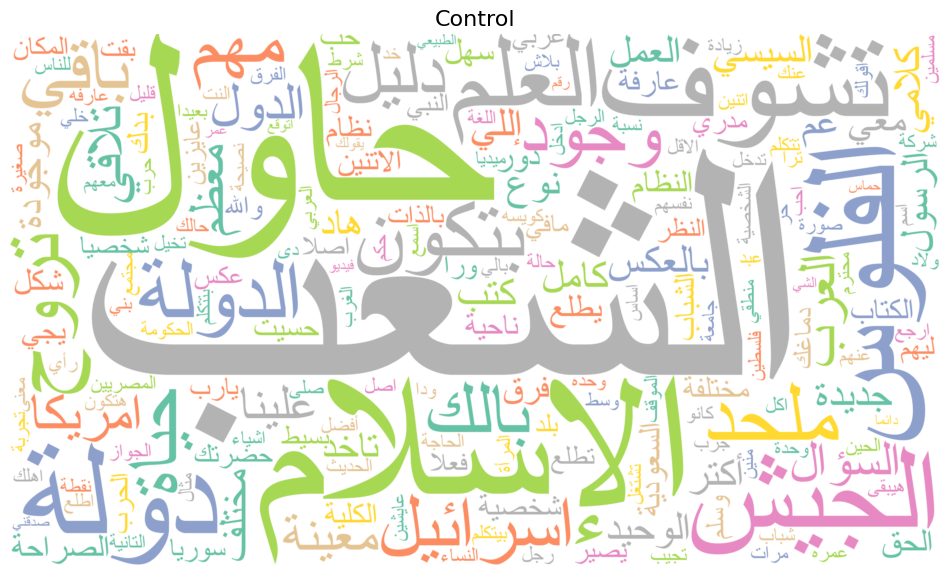


TOP 20 WORDS IN WORDCLOUD (Control)
 1. ﺍﻟﺸﻌﺐ                1.0000
 2. ﺣﺎﻭﻝ                 0.9675
 3. ﺍﻹﺳﻼﻡ                0.7725
 4. ﺗﺸﻮﻑ                 0.7555
 5. ﺍﻟﻔﻠﻮﺱ               0.7507
 6. ﺩﻭﻟﺔ                 0.7398
 7. ﺍﻟﺠﻴﺶ                0.7126
 8. ﺍﻟﻌﻠﻢ                0.6941
 9. ﺍﻟﺪﻭﻟﺔ               0.6811
10. ﺑﺘﻜﻮﻥ                0.6626
11. ﻣﻠﺤﺪ                 0.6527
12. ﺗﺮﻭﺡ                 0.6522
13. ﺍﺳﺮﺍﺋﻴﻞ              0.6410
14. ﻣﻬﻢ                  0.6392
15. ﺑﺎﻗﻲ                 0.6349
16. ﻭﺟﻮﺩ                 0.6332
17. ﺩﻟﻴﻞ                 0.6296
18. ﺣﻴﺎﺓ                 0.6255
19. ﺑﺎﻟﻚ                 0.6245
20. ﺍﻣﺮﻳﻜﺎ               0.6225
21. ﺍﻟﻌﺮﺏ                0.6182
22. ﻣﻌﻴﻨﺔ                0.6144
23. ﺍﻟﺪﻭﻝ                0.6090
24. ﺗﻼﻗﻲ                 0.6032
25. ﺍﻟﺴﺆﺍﻝ               0.5963
26. ﻋﻠﻴﻨﺎ                0.5958
27. ﻣﻌﻈﻢ                 0.5895
28. ﺍﻟﺴﻴﺴﻲ               0.5821
29. ﺑﺎﻟﻌﻜﺲ               0.5788
30. ﺍﻟﻮﺣﻴﺪ               0.5768
31.

['ﺍﻟﺸﻌﺐ',
 'ﺣﺎﻭﻝ',
 'ﺍﻹﺳﻼﻡ',
 'ﺗﺸﻮﻑ',
 'ﺍﻟﻔﻠﻮﺱ',
 'ﺩﻭﻟﺔ',
 'ﺍﻟﺠﻴﺶ',
 'ﺍﻟﻌﻠﻢ',
 'ﺍﻟﺪﻭﻟﺔ',
 'ﺑﺘﻜﻮﻥ',
 'ﻣﻠﺤﺪ',
 'ﺗﺮﻭﺡ',
 'ﺍﺳﺮﺍﺋﻴﻞ',
 'ﻣﻬﻢ',
 'ﺑﺎﻗﻲ',
 'ﻭﺟﻮﺩ',
 'ﺩﻟﻴﻞ',
 'ﺣﻴﺎﺓ',
 'ﺑﺎﻟﻚ',
 'ﺍﻣﺮﻳﻜﺎ',
 'ﺍﻟﻌﺮﺏ',
 'ﻣﻌﻴﻨﺔ',
 'ﺍﻟﺪﻭﻝ',
 'ﺗﻼﻗﻲ',
 'ﺍﻟﺴﺆﺍﻝ',
 'ﻋﻠﻴﻨﺎ',
 'ﻣﻌﻈﻢ',
 'ﺍﻟﺴﻴﺴﻲ',
 'ﺑﺎﻟﻌﻜﺲ',
 'ﺍﻟﻮﺣﻴﺪ',
 'ﻛﺎﻣﻞ',
 'ﺟﺪﻳﺪﺓ',
 'ﻛﺘﺐ',
 'ﺇﻟﻠﻲ',
 'ﻛﻼﻣﻲ',
 'ﻋﻢ',
 'ﻣﻮﺟﻮﺩﺓ',
 'ﺍﻟﺮﺳﻮﻝ',
 'ﺃﻛﺘﺮ',
 'ﺍﻟﻌﻤﻞ',
 'ﻣﺨﺘﻠﻒ',
 'ﻧﻮﻉ',
 'ﻫﺎﺩ',
 'ﻣﻌﻲ',
 'ﺗﺎﺧﺪ',
 'ﺍﻟﺼﺮﺍﺣﺔ',
 'ﻓﺮﻕ',
 'ﺳﻬﻞ',
 'ﺷﻜﻞ',
 'ﺍﻟﺴﻌﻮﺩﻳﺔ']

In [ ]:
column_to_wordcloud(df_conct[(df_conct["condition"]=="control")],"selftext",font_file,stopwords, "Control")


# finetuning

We are performing PLM finetuning on two expirments:
*    Binary Classification of each condition Vs Control (User Level)
*    Multi-Class classification on comorbid cases Vs Control (User Level)

**Data:**

you will be provided with a train and test splits for each condition. these need to be STANDARD, meaning they cannot be changed and there fore will be assigned to you.

**Models considered:**
1.    ````qwen3-235b-a22b-instruct-2507```` (Proven to be good on annotating the dataset)

2.   ````Jais-2-8B-Chat````  (Proven to be good on annotating the dataset)
3.   ````aubmindlab/bert-base-arabertv02-twitter```` (Performed well on previosu carma data)
4.   ````CAMeL-Lab/bert-base-arabic-camelbert-mix```` (Performed well on previosu carma data)

**Methodology**
* After each of those models is loaded, we will replace its output head into a binary output (diagnosed/control) because we're doing each conditions separately.
* We pass training split through the model on a single epoch calculating eval and train loss. hyperparameters need to be consistent across all four models.





In [ ]:
# Reddit data
base = "splits"
